# SHAP Explainability — Understanding Model Predictions

This notebook uses SHAP (SHapley Additive exPlanations) values to interpret the LightGBM mortality prediction model. SHAP decomposes each individual prediction into contributions from each feature, providing both global feature importance and local explanations of individual patient predictions.

## Why this matters

A model that achieves AUC 0.83 is useful only to the extent that I can trust its decisions. SHAP enables three kinds of analysis:

1. **Global feature importance** — which features the model relies on most, across all predictions
2. **Feature impact direction** — for each feature, do high values push toward death or survival?
3. **Individual patient explanations** — for any specific patient, which features drove their predicted mortality risk?

These analyses help validate that the model is learning clinically reasonable patterns (e.g., higher creatinine → higher risk) rather than spurious correlations.

## Setup and load model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import lightgbm as lgb

from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the trained LightGBM model
model = joblib.load("../models/lightgbm_model.pkl")
print(f"Loaded model: {type(model).__name__}")
print(f"Model trees: {model.n_estimators}")

Loaded model: LGBMClassifier
Model trees: 56


## Reload features and recreate train/test split

In [2]:
features = pd.read_parquet("../data/features_final.parquet")

target_col = "in_hospital_mortality"
id_col = "patientunitstayid"
categorical_cols = ["unittype", "numbedscategory", "region"]
numeric_cols = [
    c for c in features.columns 
    if c not in [id_col, target_col] + categorical_cols
]
feature_cols = numeric_cols + categorical_cols

X = features[feature_cols].copy()
for col in categorical_cols:
    X[col] = X[col].astype("category")
y = features[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Test set: {X_test.shape}")

Test set: (285, 100)


## Compute SHAP values

In [3]:
# TreeExplainer is the fast, exact SHAP implementation for tree-based models
explainer = shap.TreeExplainer(model)

# Compute SHAP values for all test set patients
# This produces a matrix where each cell is "how much did feature X push patient Y's prediction"
shap_values = explainer.shap_values(X_test)

# For binary classification with newer LightGBM/SHAP, this is a 2D array of shape (n_samples, n_features)
# representing SHAP values for the positive class (death)
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Expected: ({X_test.shape[0]}, {X_test.shape[1]})")

# Quick sanity check: average SHAP value should be near zero
# (positive contributions to some patients balance negative contributions to others)
print(f"\nMean SHAP value across all features and patients: {np.mean(shap_values):.4f}")
print(f"(should be small — represents average effect across the dataset)")

SHAP values shape: (285, 100)
Expected: (285, 100)

Mean SHAP value across all features and patients: 0.0003
(should be small — represents average effect across the dataset)


/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Global feature importance — the headline plot

In [4]:
# Compute mean absolute SHAP value per feature — this is global importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Build a DataFrame for sorting and display
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 20 most important features (by mean absolute SHAP value):")
print(importance_df.head(20).to_string(index=False))

Top 20 most important features (by mean absolute SHAP value):
      feature  mean_abs_shap
      bun_max       0.444298
   spo2_count       0.335971
      gcs_max       0.252622
          age       0.246797
     temp_max       0.240959
    sbp_count       0.188212
     gcs_mean       0.165118
    spo2_mean       0.154257
      hr_mean       0.141245
      rr_mean       0.138445
     map_mean       0.129185
      sbp_max       0.124408
          bmi       0.101079
     spo2_min       0.101017
       rr_min       0.084634
    temp_mean       0.083497
  glucose_min       0.072998
      sbp_min       0.072292
      wbc_min       0.065581
bilirubin_min       0.063527


## SHAP summary plot — the headline visualization

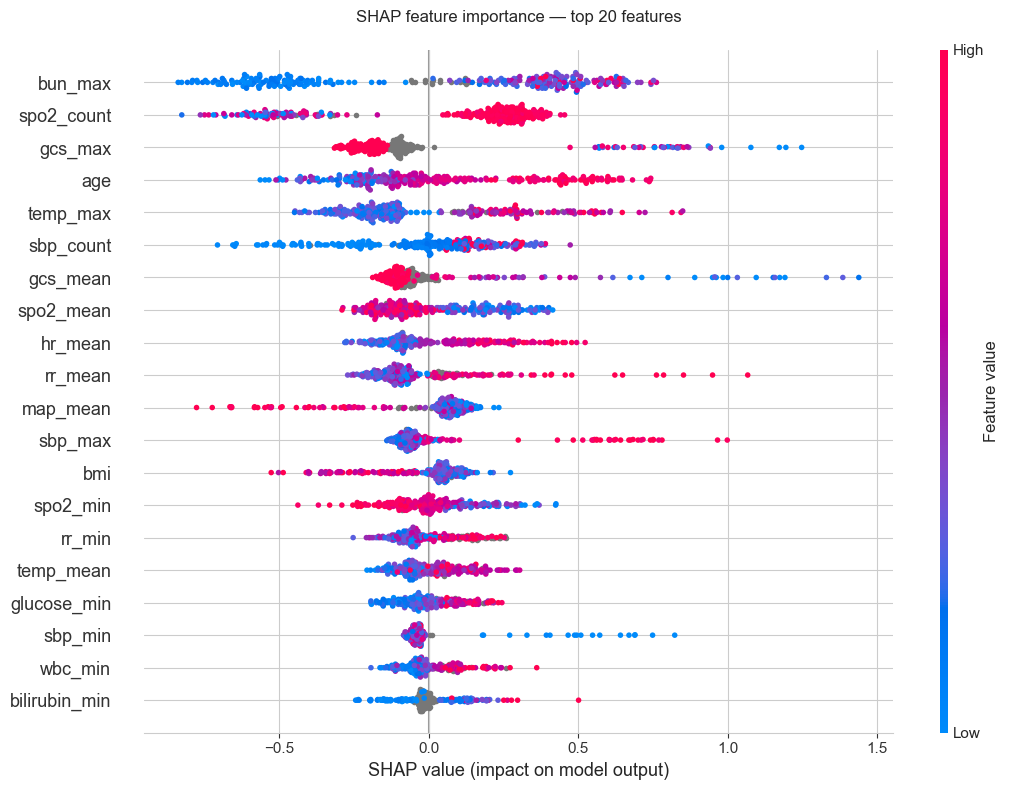

In [5]:
# SHAP summary plot — beeswarm visualization showing feature importance and direction
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False,  # we want to control the figure size and save it
)
fig = plt.gcf()
fig.set_size_inches(11, 8)
plt.title("SHAP feature importance — top 20 features", pad=20)
plt.tight_layout()
plt.show()

## Feature importance bar chart (cleaner version)

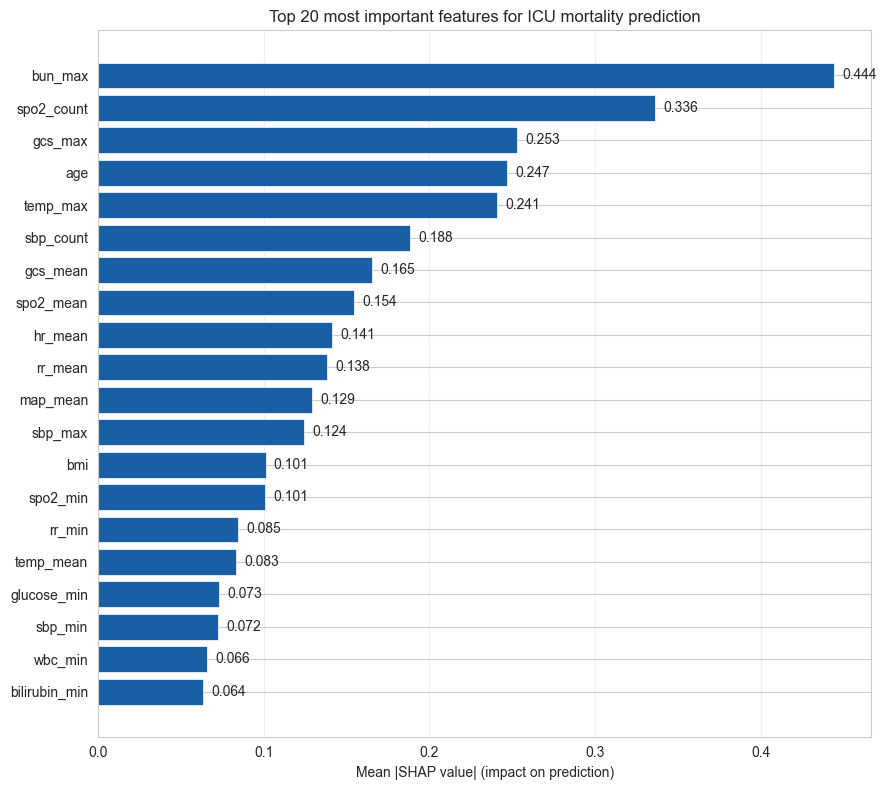

In [6]:
# Top 20 features as a horizontal bar chart
top_n = 20
top_features = importance_df.head(top_n).iloc[::-1]  # reverse so most important is at top

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(
    top_features["feature"],
    top_features["mean_abs_shap"],
    color="#185FA5",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xlabel("Mean |SHAP value| (impact on prediction)")
ax.set_title(f"Top {top_n} most important features for ICU mortality prediction")
ax.grid(alpha=0.3, axis="x")
ax.set_axisbelow(True)

# Annotate each bar with the value
for bar, value in zip(bars, top_features["mean_abs_shap"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{value:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## Individual patient explanations

High-risk patient: predicted probability of death = 0.859
  Actual outcome: Died

Low-risk patient: predicted probability of death = 0.005
  Actual outcome: Survived

=== High-risk patient explanation ===


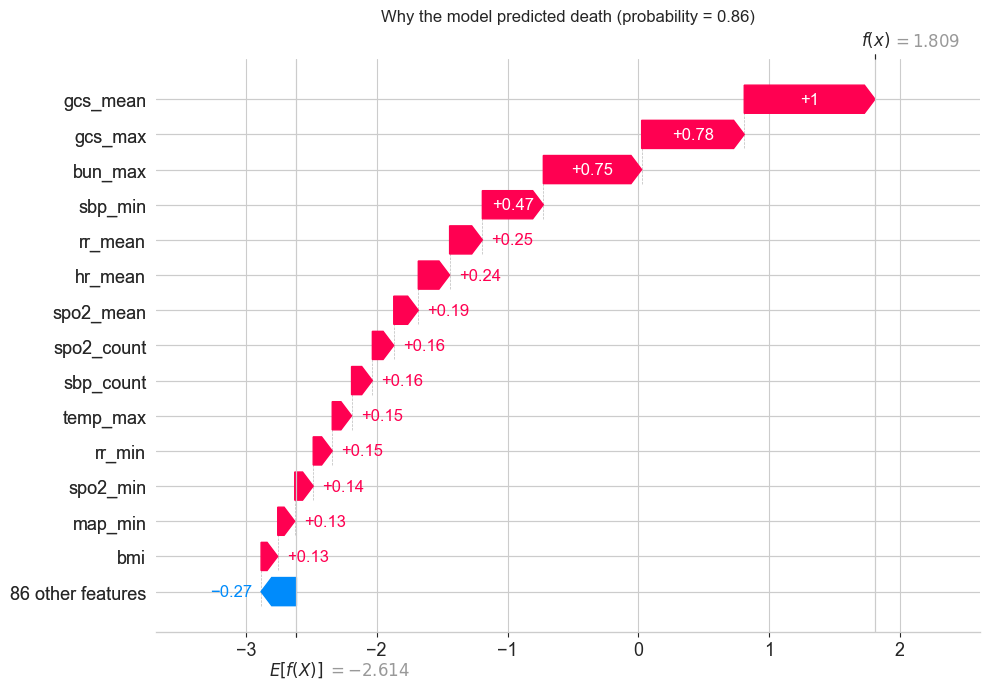

In [7]:
# Get predictions for context
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Find a high-confidence death prediction and a high-confidence survival prediction
high_risk_idx = np.argmax(y_pred_proba)  # patient most predicted to die
low_risk_idx = np.argmin(y_pred_proba)   # patient most predicted to survive

print(f"High-risk patient: predicted probability of death = {y_pred_proba[high_risk_idx]:.3f}")
print(f"  Actual outcome: {'Died' if y_test.iloc[high_risk_idx] == 1 else 'Survived'}")
print()
print(f"Low-risk patient: predicted probability of death = {y_pred_proba[low_risk_idx]:.3f}")
print(f"  Actual outcome: {'Died' if y_test.iloc[low_risk_idx] == 1 else 'Survived'}")

# Waterfall plot for high-risk patient
print("\n=== High-risk patient explanation ===")
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[high_risk_idx],
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=False,
)
fig = plt.gcf()
fig.set_size_inches(10, 7)
plt.title(f"Why the model predicted death (probability = {y_pred_proba[high_risk_idx]:.2f})")
plt.tight_layout()
plt.show()